# Same-day-expiry nearest-out-of-the-money call and put, 15:30 → 16:00

One trade per expiration day. At 15:30 ET the "at-the-money" package is
defined as the **nearest out-of-the-money** legs:

- call: the smallest listed strike $K_c \ge S$ with a live midpoint quote
- put: the largest listed strike $K_p \le S$ with a live midpoint quote

When the index sits exactly on a strike the two legs share it and the
package is a straddle; otherwise it is a strangle one strike wide. The
package is held to the close and settled in cash against the official
S&P 500 close (yfinance `^GSPC`): the call pays
$\max(S_{\mathrm{close}}-K_c,0)$ and the put pays
$\max(K_p-S_{\mathrm{close}},0)$.

The signal compares the forecast of realized variance over the final
half hour with the variance the option market quotes for that same
half hour, both in variance units:
$s=\widehat{RV}-(\mathrm{IV}_{\mathrm{hourly}}/\sqrt{2})^2$, where
$\widehat{RV}=(m^2+\hat\sigma^2)B$ is the model's forecast mapped onto
the realized scale by a recalibration estimated from past data only
(§7). Two position rules are scored on the same 871 days. The headline
is the **$\mathrm{sign}(s)$** portfolio, which sells the package when the market's
quoted variance exceeds the forecast and buys it otherwise: on the
block-diagonal ridge forecast it earns an annualized Sharpe ratio of
1.63 ($t = 3.03$). The **always-short** portfolio, which uses no forecast, is
the control, at a Sharpe ratio of 0.28.

The notebook runs as follows. Sections 1–6 build the instrument and its
return; §7 loads the variance forecasts and recalibrates them; §8 puts
the quoted implied volatility in the same units; §9 forms the signal and
the position; §10 tabulates the two rules across the seven forecasts;
§11 regresses the settlement return on the 15:30 signal; §12 adds up
the profit and loss; §13 reports information ratios against the
always-short portfolio; §14 compounds each rule at a fixed 3% of wealth per day; §15 diagnoses the buy days; §16 checks one row by hand. A
defined-risk variant (wings on the days the portfolio sells) is parked and
explored in the experimental notebook.

Volatility-scale views of the forecasts ($\hat y\sqrt{B}$, $m\sqrt{B}$)
are in `atm_straddle_volmap.ipynb` where present and otherwise in
`atm_straddle_experimental.ipynb`; ensembles and alternative weightings
are in `atm_straddle_experimental.ipynb`; the every-half-hour version of
this trade is in `atm_straddle_intraday.ipynb`.

Every cell reads from `data/` or from a table built by the cell before
it, and prints each table before using it.

In [1]:
import hashlib
import os
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import statsmodels.api as sm

def find_repo(start: Path) -> Path:
    for q in [start.resolve(), *start.resolve().parents]:
        if (q / "data" / "spxw_chain.parquet").exists():
            return q
    raise FileNotFoundError("repo root not found")

REPO = find_repo(Path.cwd())
OUT = REPO / "results" / "atm_straddle_0dte_1530"
OUT.mkdir(parents=True, exist_ok=True)
# derived-input cache: every entry is keyed on the source file's
# size+mtime (and the request), so a changed input can never serve a
# stale hit. Delete the directory to force a cold rebuild.
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 24)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Load the option chain (15:30 and 16:00 ET only)

The source file, `data/spxw_chain.parquet`, holds a quote for every
30-minute time stamp. This trade needs only the 15:30 quotes, which are
the entry prices; the 16:00 rows are kept solely to compare the tape's
underlying price against the official close. The load therefore reads
the time stamps first, keeps those two Eastern times of day, and only
then loads the remaining columns for those rows.

In [2]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = [
    "expiration",
    "timestamp",
    "strike",
    "cp",
    "bid",
    "ask",
    "mid",
    "underlying_price",
    "impl_volatility",
]
_st = os.stat(path)
_ck = CACHE / f"chain_15301600_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
    print(f"cache hit {_ck.name} (source size+mtime matched; "
          "full-file stamp scan skipped)")
else:
    ts = pd.to_datetime(pd.read_parquet(path, columns=["timestamp"])["timestamp"], utc=True)
    et = ts.dt.tz_convert("America/New_York")
    keep = ts[
        ((et.dt.hour == 15) & (et.dt.minute == 30)) | ((et.dt.hour == 16) & (et.dt.minute == 0))
    ].unique()
    print("unique timestamps in file", ts.nunique())
    print("15:30/16:00 ET stamps kept", len(keep))
    del ts, et
    chain = pd.read_parquet(path, columns=COLS, filters=[("timestamp", "in", list(keep))])
    chain["timestamp"] = pd.to_datetime(chain["timestamp"], utc=True)
    chain["expiration"] = pd.to_datetime(chain["expiration"])
    chain["cp"] = chain["cp"].astype(str).str.upper().str[0]
    for _old in CACHE.glob("chain_15301600_*.parquet"):
        _old.unlink()
    chain.to_parquet(_ck)
print("rows", f"{len(chain):,}")
print("columns", list(chain.columns))
print("timestamp", chain["timestamp"].min(), "->", chain["timestamp"].max())
print("expirations", chain["expiration"].nunique())
print(chain.head(3))


cache hit chain_15301600_77439812_1786671584951439500.parquet (source size+mtime matched; full-file stamp scan skipped)
rows 1,171,254
columns ['expiration', 'timestamp', 'strike', 'cp', 'bid', 'ask', 'mid', 'underlying_price', 'impl_volatility']
timestamp 2020-01-03 20:30:00+00:00 -> 2025-12-31 21:00:00+00:00
expirations 1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000


## 2. Times of day and the same-day-expiry flag

The vendor's time stamps are in UTC; the trading session runs on New
York time. A quote row is same-day expiry (0DTE) when the Eastern
calendar date of its time stamp equals the option's expiration date.

In [3]:
# ~3M rows share ~4k unique stamps: convert clocks once per unique
# value and take() back, instead of per-row strftime/tz work.
codes, uts = pd.factorize(chain["timestamp"])
assert (codes >= 0).all(), "null timestamp in chain"
uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
chain["et"] = uet.take(codes)
hh = np.where(
    (uet.hour == 15) & (uet.minute == 30), "15:30",
    np.where((uet.hour == 16) & (uet.minute == 0), "16:00", "other"),
)
chain["hhmm"] = hh[codes]
chain["et_date"] = uet.normalize().take(codes)
ecodes, uexp = pd.factorize(chain["expiration"])
assert (ecodes >= 0).all(), "null expiration in chain"
uexp_d = (
    pd.DatetimeIndex(uexp)
    .tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT")
    .normalize()
)
chain["exp_date"] = uexp_d.take(ecodes)
chain["is_0dte"] = chain["et_date"] == chain["exp_date"]
print("0DTE rows", f"{int(chain['is_0dte'].sum()):,}", "/", f"{len(chain):,}")
print("ET hour counts on 0DTE:")
print(chain.loc[chain["is_0dte"], "et"].dt.hour.value_counts().sort_index().to_string())
print("15:30 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "15:30"), "timestamp"].nunique())
print("16:00 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "16:00"), "timestamp"].nunique())


0DTE rows 1,171,254 / 1,171,254
ET hour counts on 0DTE:
et
15    585627
16    585627


15:30 0DTE stamps 1291
16:00 0DTE stamps 1291


## 3. Keep only same-day-expiry rows at those two times

The 15:30 quote is the entry. The 16:00 rows serve only the
tape-versus-close check; settlement uses the official close from
yfinance (`^GSPC`), never a 16:00 option quote. The load already dropped
the other hours; this step drops whatever is not an expiration-day row.

In [4]:
book_chain = chain[chain["is_0dte"] & chain["hhmm"].isin(["15:30", "16:00"])].copy()
print("rows", f"{len(book_chain):,}")
print(book_chain.groupby("hhmm").agg(rows=("strike", "size"), days=("expiration", "nunique"), stamps=("timestamp", "nunique")))
print(book_chain.head(3))
del chain


rows 1,171,254


         rows  days  stamps
hhmm                       
15:30  585627  1291    1291
16:00  585627  1291    1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility                        et  \
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000 2020-01-03 15:30:00-05:00   
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000 2020-01-03 16:00:00-05:00   
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000 2020-01-03 15:30:00-05:00   

    hhmm                   et_date                  exp_date  is_0dte  
0  15:30 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
1  16:00 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
2  15:30 2020-01-03 00:00:00-05:00 2020-01-03 00:00

## 4. Nearest out-of-the-money call and put at 15:30

The index level $S$ is the 15:30 print. Among quotes with a finite,
positive midpoint:

- call: the smallest strike $K_c \ge S$
- put: the largest strike $K_p \le S$

The number of days that lose a leg is printed. The entry price is
$\mathrm{mid}(K_c) + \mathrm{mid}(K_p)$.

In [5]:
e = book_chain[book_chain["hhmm"] == "15:30"].copy()
n_days = e["expiration"].nunique()
live = e[np.isfinite(e["mid"]) & (e["mid"] > 0)].copy()
live["S"] = live["underlying_price"].astype(float)
spot = live.dropna(subset=["S"]).groupby("expiration")["S"].first()
print("15:30 0DTE days", n_days, "with a spot", int(spot.notna().sum()))
print("15:30 0DTE rows", f"{len(e):,}", "with finite mid>0", f"{len(live):,}",
      f"({len(live) / max(len(e), 1):.1%} of rows)")

c = live[live["cp"] == "C"].copy()
p = live[live["cp"] == "P"].copy()
c["S"] = c["expiration"].map(spot)
p["S"] = p["expiration"].map(spot)
c = c[np.isfinite(c["S"])]
p = p[np.isfinite(p["S"])]

c_otm = c[c["strike"] >= c["S"]].copy()
c_otm["k_gap"] = c_otm["strike"].astype(float) - c_otm["S"]
c_pick = (
    c_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
p_otm = p[p["strike"] <= p["S"]].copy()
p_otm["k_gap"] = p_otm["S"] - p_otm["strike"].astype(float)
p_pick = (
    p_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
print("days with a nearest-OTM call (K>=S, live mid)", len(c_pick))
print("days with a nearest-OTM put  (K<=S, live mid)", len(p_pick))
print("days missing OTM call", n_days - len(c_pick), "missing OTM put", n_days - len(p_pick))

atm = c_pick.merge(p_pick, on="expiration", suffixes=("_c", "_p"))
atm["S"] = atm["S_c"].astype(float)
atm["K_c"] = atm["strike_c"].astype(float)
atm["K_p"] = atm["strike_p"].astype(float)
atm["entry"] = atm["mid_c"].astype(float) + atm["mid_p"].astype(float)
atm["day"] = atm["et_c"].dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
atm["same_strike"] = atm["K_c"] == atm["K_p"]
print("days with both legs", len(atm), "dropped", n_days - len(atm))
print("frac same strike (spot on a listed K)", float(atm["same_strike"].mean()))
print("median K_c - S", float((atm["K_c"] - atm["S"]).median()),
      "median S - K_p", float((atm["S"] - atm["K_p"]).median()))
print(atm[["expiration", "S", "K_c", "K_p", "mid_c", "mid_p", "entry", "same_strike"]].head(8))
print("---")
print(atm[["S", "K_c", "K_p", "entry"]].describe())


15:30 0DTE days 1291 with a spot 1291
15:30 0DTE rows 585,627 with finite mid>0 585,532 (100.0% of rows)


days with a nearest-OTM call (K>=S, live mid) 1291
days with a nearest-OTM put  (K<=S, live mid) 1291
days missing OTM call 0 missing OTM put 0
days with both legs 1291 dropped 0
frac same strike (spot on a listed K) 0.000774593338497289
median K_c - S 2.5400390625 median S - K_p 2.4599609375
  expiration            S          K_c          K_p     mid_c     mid_p     entry  same_strike
0 2020-01-03  3238.300049  3240.000000  3235.000000  1.300000  1.250000  2.550000        False
1 2020-01-06  3240.540039  3245.000000  3240.000000  0.200000  1.450000  1.650000        False
2 2020-01-08  3266.530029  3270.000000  3265.000000  0.525000  1.000000  1.525000        False
3 2020-01-10  3267.570068  3270.000000  3265.000000  1.150000  1.300000  2.450000        False
4 2020-01-13  3282.340088  3285.000000  3280.000000  0.550000  0.675000  1.225000        False
5 2020-01-15  3284.679932  3285.000000  3280.000000  1.950000  0.675000  2.625000        False
6 2020-01-17  3324.280029  3325.000000  3

## 5. Exit: cash settlement at the official close

Each leg settles in cash at its intrinsic value against the official
S&P 500 close (`^GSPC` from yfinance), not against a 16:00 option
quote:

- call: $\max(S_{\mathrm{close}}-K_c, 0)$
- put: $\max(K_p-S_{\mathrm{close}}, 0)$

If the close lands between $K_p$ and $K_c$, both legs expire worthless
and the settlement is zero. As a check, the gap between this close and
the 16:00 underlying on the option tape is printed.

In [6]:
def load_gspc_close(days: pd.Series) -> pd.Series:
    days = pd.to_datetime(days)
    start = pd.Timestamp(days.min()) - pd.Timedelta("7D")
    end = pd.Timestamp(days.max()) + pd.Timedelta("7D")
    cp = CACHE / "gspc_close.parquet"
    if cp.exists():
        cached = pd.read_parquet(cp)["close"]
        cached.index = pd.to_datetime(cached.index)
        if cached.index.min() <= pd.Timestamp(days.min()) and cached.index.max() >= pd.Timestamp(days.max()):
            print(f"cache hit {cp.name} (covers {cached.index.min().date()} .. {cached.index.max().date()})")
            return cached.astype(float)
    raw = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False, threads=True)
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    ix = pd.to_datetime(close.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    close.index = ix.normalize()
    close = close.astype(float)
    close.rename("close").to_frame().to_parquet(cp)
    return close


atm = atm.reset_index(drop=True)
exp_day = pd.to_datetime(atm["expiration"])
if getattr(exp_day.dt, "tz", None) is not None:
    exp_day = exp_day.dt.tz_convert("America/New_York").dt.tz_localize(None)
exp_day = exp_day.dt.normalize()
atm["S_close"] = exp_day.map(load_gspc_close(exp_day))

x = book_chain[book_chain["hhmm"] == "16:00"]
s_tape = (
    x.dropna(subset=["underlying_price"])
    .groupby("expiration")["underlying_price"]
    .first()
)
atm["S_1600_tape"] = atm["expiration"].map(s_tape).astype(float)
gap = (atm["S_close"] - atm["S_1600_tape"]).abs()
print("yfinance ^GSPC close vs 16:00 chain underlying")
print(pd.DataFrame({
    "S_close": atm["S_close"],
    "S_1600_tape": atm["S_1600_tape"],
    "abs_gap": gap,
}).describe())
print("days missing yfinance close", int(atm["S_close"].isna().sum()))
print("median |close - tape|", float(gap.median()) if gap.notna().any() else float("nan"))

atm["pay_c"] = np.maximum(atm["S_close"] - atm["K_c"], 0.0)
atm["pay_p"] = np.maximum(atm["K_p"] - atm["S_close"], 0.0)
atm["exit"] = atm["pay_c"] + atm["pay_p"]
print(atm[["expiration", "S", "K_c", "K_p", "S_close", "S_1600_tape", "pay_c", "pay_p", "entry", "exit"]].head(8))
print("frac settlement 0 (close between K_p and K_c)", float((atm["exit"] == 0).mean()))
atm = atm[np.isfinite(atm["entry"]) & np.isfinite(atm["exit"]) & (atm["entry"] > 0)].copy()


cache hit gspc_close.parquet (covers 2019-12-27 .. 2026-01-06)


yfinance ^GSPC close vs 16:00 chain underlying
           S_close  S_1600_tape      abs_gap
count  1291.000000  1291.000000  1291.000000
mean   4708.704570  4708.780010     0.534863
std    1031.543891  1031.522314     0.574065
min    2237.399902  2236.300049     0.000000
25%    3971.940063  3971.824951     0.160156
50%    4455.479980  4455.560059     0.379883
75%    5572.459961  5572.514893     0.709961
max    6932.049805  6932.049805     5.909912
days missing yfinance close 0
median |close - tape| 0.3798828125
  expiration            S          K_c          K_p      S_close  S_1600_tape     pay_c      pay_p     entry       exit
0 2020-01-03  3238.300049  3240.000000  3235.000000  3234.850098  3234.350098  0.000000   0.149902  2.550000   0.149902
1 2020-01-06  3240.540039  3245.000000  3240.000000  3246.280029  3246.229980  1.280029   0.000000  1.650000   1.280029
2 2020-01-08  3266.530029  3270.000000  3265.000000  3253.050049  3253.209961  0.000000  11.949951  1.525000  11.949951
3 2

## 6. Return $R = \mathrm{exit}/P_{15:30} - 1$

The package costs its entry price at 15:30 and pays the two legs'
settlement values in cash at the close; $R$ is that payout divided by
the entry price, minus one.

In [7]:
atm["R"] = atm["exit"] / atm["entry"] - 1.0
atm = atm.set_index("day").sort_index()
print(atm[["expiration", "K_c", "K_p", "entry", "exit", "R"]].head(8))
print("---")
print(atm["R"].describe())
print("n", len(atm))


           expiration          K_c          K_p     entry       exit         R
day                                                                           
2020-01-03 2020-01-03  3240.000000  3235.000000  2.550000   0.149902 -0.941215
2020-01-06 2020-01-06  3245.000000  3240.000000  1.650000   1.280029 -0.224225
2020-01-08 2020-01-08  3270.000000  3265.000000  1.525000  11.949951  6.836034
2020-01-10 2020-01-10  3270.000000  3265.000000  2.450000   0.000000 -1.000000
2020-01-13 2020-01-13  3285.000000  3280.000000  1.225000   3.129883  1.555006
2020-01-15 2020-01-15  3285.000000  3280.000000  2.625000   4.290039  0.634301
2020-01-17 2020-01-17  3325.000000  3320.000000  2.325000   4.620117  0.987147
2020-01-21 2020-01-21  3325.000000  3320.000000  1.550000   0.000000 -1.000000
---
count    1291.000000
mean       -0.033629
std         1.124668
min        -1.000000
25%        -0.947002
50%        -0.335511
75%         0.400174
max        10.316049
Name: R, dtype: float64
n 1291


## 7. Variance forecasts

**Which half-hour bar.** The forecast table labels every bar by the
time it *ends*: the row labelled 16:00 holds the realized variance of
the 15:30–16:00 bar and the forecast of that bar, issued at 15:30. The
15:30 trade must therefore read the **row labelled 16:00** — the
forecast for the very bar it trades, made with nothing observed after
15:30. The row labelled 15:30 is the forecast of the 15:00–15:30 bar:
also free of look-ahead, but one bar stale. (An earlier version of this
notebook used it.)

**Seven forecasts**, one stored table each, all from the paper's
pipeline on the same panel:

- baseline (HAR + calendar OLS);
- block-diagonal ridge — the paper's headline model, with the FOMC
  calendar columns in its design;
- LightGBM and XGBoost on the wide all-features design, frozen settings;
- the lasso on that design with its penalty chosen from past data only,
  and the lasso at a fixed penalty of $10^{-4}$;
- the elastic net, penalties chosen from past data only.

**From stored forecast to a variance.** Forecasts are stored on the
fitted scale $y=\sqrt{RV/B}$ ($B$ the time-of-day profile), winsorized.
Each is mapped to a 30-minute variance by a Mincer–Zarnowitz
recalibration fitted on the trailing 250 days only:

- fit $m=a+b\,\hat y$ and the residual variance $\hat\sigma^2$ against
  the unwinsorized realized $\sqrt{RV/B}$, by weighted least squares
  with weights $1/\max(\hat y, q_{10})^2$ ($q_{10}$ the window's tenth
  percentile of $\hat y$);
- $\widehat{RV}=(m^2+\hat\sigma^2)\,B$ — the expected realized variance
  of the 15:30–16:00 bar;
- the fit uses only the bars the paper scores, 10:00 to 16:00; bars
  outside that window are mispredicted by a factor of 50 to 100 and,
  when they were included, pushed the forecast-to-realized ratio from
  1.08 to 1.14.

Housekeeping: the fit is solved in closed form one day at a time, in a
routine shared with the intraday notebook; each model's table is cached
and keyed to its inputs, so unchanged inputs skip the computation and
any change forces it; the seven tables load in parallel.

In [8]:
from concurrent.futures import ThreadPoolExecutor

YHATS = {
    "a0": REPO / "results" / "spxw_pnl" / "yhat_a0.parquet",
    "blk2": REPO / "results" / "spxw_pnl" / "yhat_blk2_fomc1.parquet",
    "lgbm": REPO / "results" / "spxw_pnl" / "yhat_tree00.parquet",
    "xgb": REPO / "results" / "spxw_pnl" / "yhat_tree16.parquet",
    "lasso_t": REPO / "results" / "spxw_pnl" / "yhat_b2lasso_tuned.parquet",
    "lasso_f": REPO / "results" / "spxw_pnl" / "yhat_b2lasso.parquet",
    "enet": REPO / "results" / "spxw_pnl" / "yhat_b3enet_tuned.parquet",
}
# The second-order map (MZ smear) lives in atm_straddle_lib: flat
# 250-day window, fit restricted to the scored session bars
# (10:00-15:30 ET) so off-session dynamics cannot pollute the
# calibration. Delegate rather than duplicate.
import sys
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl

second_order_raw = asl.second_order_raw
load_yhat_1530 = asl.load_yhat_1530


def load_yhat_1530_cached(tag: str, path: Path, need_dates) -> pd.DataFrame:
    h = hashlib.sha1()
    st = os.stat(path)
    h.update(f"v6-vec-gls:{st.st_size}:{st.st_mtime_ns}:flat{asl.WINDOW_DAYS}".encode())
    for d in sorted(need_dates):
        h.update(str(d).encode())
    cp = CACHE / f"yhat1530_{tag}_{h.hexdigest()[:16]}.parquet"
    if cp.exists():
        return pd.read_parquet(cp)
    out = load_yhat_1530(path, need_dates)
    for old in CACHE.glob(f"yhat1530_{tag}_*.parquet"):
        old.unlink()
    out.to_parquet(cp)
    return out


need_dates = set(atm.index)
with ThreadPoolExecutor(max_workers=len(YHATS)) as pool:
    futs = {
        tag: pool.submit(load_yhat_1530_cached, tag, path, need_dates)
        for tag, path in YHATS.items()
    }
    models = {tag: futs[tag].result() for tag in YHATS}

LABEL = {
    "a0": "baseline (HAR + calendar OLS)",
    "blk2": "block-diag ridge",
    "lgbm": "LightGBM",
    "xgb": "XGBoost",
    "lasso_t": "lasso (causally tuned)",
    "lasso_f": "lasso (fixed 1e-4)",
    "enet": "elastic net (causally tuned)",
}
print("option days", len(atm), pd.Timestamp(atm.index.min()), "->", pd.Timestamp(atm.index.max()))
for tag, rv in models.items():
    n_ov = atm.index.intersection(rv.index).nunique()
    print(f"{LABEL[tag]}: 15:30 days {len(rv)}  {pd.Timestamp(rv.index.min())} -> {pd.Timestamp(rv.index.max())}  "
          f"days in both {n_ov}  option days with no forecast {len(atm) - n_ov}")
    print(rv.head(3)[["yhat", "baseline", "rv_hat", "rv_raw"]])
    print("median rv_hat", float(rv["rv_hat"].median()),
          "median rv_raw", float(rv["rv_raw"].median()))
    print("---")


option days 1291 2020-01-03 00:00:00 -> 2025-12-31 00:00:00
baseline (HAR + calendar OLS): 15:30 days 871  2020-01-03 00:00:00 -> 2024-04-30 00:00:00  days in both 871  option days with no forecast 420
                yhat  baseline    rv_hat    rv_raw
date                                              
2020-01-03  1.543206  0.000001  0.000004  0.000004
2020-01-06  1.012508  0.000001  0.000002  0.000001
2020-01-08  1.158877  0.000001  0.000002  0.000004
median rv_hat 4.498853487981324e-06 median rv_raw 4.233099274555844e-06
---
block-diag ridge: 15:30 days 871  2020-01-03 00:00:00 -> 2024-04-30 00:00:00  days in both 871  option days with no forecast 420
                yhat  baseline    rv_hat    rv_raw
date                                              
2020-01-03  1.764510  0.000001  0.000004  0.000004
2020-01-06  1.073883  0.000001  0.000002  0.000001
2020-01-08  1.111637  0.000001  0.000002  0.000004
median rv_hat 4.788166332870916e-06 median rv_raw 4.233099274555844e-06
---
LightGB

## 8. Putting implied volatility on the same footing as realized variance

The option chain carries an implied-volatility column for each leg. Its
units decide whether the signal makes sense, and the reading used here
rests on two sources.

- **The field's definition.** The intraday SPXW chain and its
  implied-volatility field are Chris Jones's data, and the field is a
  **one-hour standard deviation** of the index return — not an
  annualized volatility, which is the convention of end-of-day vendors
  such as OptionMetrics and does not apply to this chain. At the money
  the values are about $0.002$: read as annualized that is a hundred
  times too small for quotes that price roughly 20% annualized
  volatility; read as a one-hour standard deviation it is exactly right.
- **A check against the market's own prices.** Pricing the 15:30
  package with the Black–Scholes–Merton formula (Black and Scholes,
  1973; Merton, 1973) over the remaining half hour, with the one-hour
  figure scaled to thirty minutes, reproduces the quoted midpoint to
  quote precision, while the other candidate readings — a thirty-minute,
  a daily, or an annualized standard deviation — miss by large factors.
  The check is reported in the paper's methods for the last-bar option
  reading; this notebook uses the quoted field directly and performs no
  inversion of its own.

Scaling to the window that remains at 15:30:

$$
\mathrm{IV}_{30}=\mathrm{IV}_{\mathrm{hourly}}/\sqrt{2},\qquad
\mathrm{iv\_var}=\mathrm{IV}_{30}^{2}=(\mathrm{IV}_{\mathrm{hourly}})^{2}/2
\approx 2\times 10^{-6},
$$

the same scale as the realized-variance forecast $\widehat{RV}$. Because
thirty minutes is all that remains at 15:30, this is also the implied
variance of the rest of the session.

In [9]:
atm["iv_c"] = pd.to_numeric(atm["impl_volatility_c"], errors="coerce")
atm["iv_p"] = pd.to_numeric(atm["impl_volatility_p"], errors="coerce")
atm["iv_hourly"] = atm[["iv_c", "iv_p"]].mean(axis=1)
atm["iv_30"] = atm["iv_hourly"] / np.sqrt(2.0)
atm["iv_var"] = atm["iv_30"] ** 2
print(atm[["S", "K_c", "K_p", "entry", "iv_hourly", "iv_30", "iv_var"]].head(8))
print("---")
print(atm[["iv_hourly", "iv_30", "iv_var"]].describe())
print("days missing quoted IV", int(atm["iv_hourly"].isna().sum()))


                      S          K_c          K_p     entry  iv_hourly     iv_30    iv_var
day                                                                                       
2020-01-03  3238.300049  3240.000000  3235.000000  2.550000   0.002523  0.001784  0.000003
2020-01-06  3240.540039  3245.000000  3240.000000  1.650000   0.001734  0.001226  0.000002
2020-01-08  3266.530029  3270.000000  3265.000000  1.525000   0.001839  0.001300  0.000002
2020-01-10  3267.570068  3270.000000  3265.000000  2.450000   0.002450  0.001732  0.000003
2020-01-13  3282.340088  3285.000000  3280.000000  1.225000   0.001675  0.001184  0.000001
2020-01-15  3284.679932  3285.000000  3280.000000  2.625000   0.002376  0.001680  0.000003
2020-01-17  3324.280029  3325.000000  3320.000000  2.325000   0.002223  0.001572  0.000002
2020-01-21  3323.949951  3325.000000  3320.000000  1.550000   0.001805  0.001276  0.000002
---


         iv_hourly        iv_30       iv_var
count  1291.000000  1291.000000  1291.000000
mean      0.003694     0.002612     0.000010
std       0.002655     0.001877     0.000026
min       0.000876     0.000620     0.000000
25%       0.002119     0.001499     0.000002
50%       0.003023     0.002138     0.000005
75%       0.004265     0.003016     0.000009
max       0.025000     0.017678     0.000313
days missing quoted IV 0


## 9. The signal and the $\mathrm{sign}(s)$ position

Both quantities are now in variance units. The signal is the gap between the forecast and the implied variance,
$s_t=\widehat{RV}_t-\bigl(\mathrm{IV}_{\mathrm{hourly},t}/\sqrt{2}\bigr)^{2}$.
The position is long the package when the signal is positive and short otherwise: $q_t=+1$ if $s_t>0$ and $q_t=-1$ if not. The position's return is $q_t R_t$.

In [10]:
def make_book(rv: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    px = atm.join(rv[["rv_hat"]], how="inner")
    px = px.dropna(subset=["R", "rv_hat", "iv_var", "entry"])
    px = px[(px["rv_hat"] > 0) & (px["iv_var"] > 0)]
    px["signal"] = px["rv_hat"] - px["iv_var"]
    px["pos"] = np.where(px["signal"] > 0, 1.0, -1.0)
    px["R_p"] = px["pos"] * px["R"]
    mu = float(px["R_p"].mean())
    sd = float(px["R_p"].std())
    r_short = -px["R"]
    stats = pd.Series({
        "n_days": len(px),
        "frac_long": float((px["pos"] > 0).mean()),
        "frac_short": float((px["pos"] < 0).mean()),
        "mean_Rp": mu,
        "Sharpe_ann": mu / sd * np.sqrt(252.0) if sd > 0 else float("nan"),
        "mean_Rp always-short": float(r_short.mean()),
        "Sharpe_ann always-short": float(r_short.mean() / r_short.std() * np.sqrt(252)),
        "start": pd.Timestamp(px.index.min()),
        "end": pd.Timestamp(px.index.max()),
    })
    return px, stats

books, stat_cols = {}, {}
for tag, rv in models.items():
    px, st = make_book(rv)
    books[tag] = px
    stat_cols[tag] = st
    px.to_parquet(OUT / f"daily_{tag}.parquet")
    print("wrote", OUT / f"daily_{tag}.parquet")

print(pd.DataFrame(stat_cols).rename(columns=LABEL).to_string())
print("---")
print("hand-check baseline (HAR + calendar OLS) (R_p = R if pos==1, else -R):")
print(books["a0"][["entry", "exit", "R", "rv_hat", "iv_hourly", "iv_30", "iv_var", "signal", "pos", "R_p"]].head(8))


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_a0.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_blk2.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lgbm.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_xgb.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lasso_t.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lasso_f.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_enet.parquet
                        baseline (HAR + calendar OLS)     block-diag ridge             LightGBM              XGBoost lasso (causally tuned)   lasso (fixed 1e-4) elastic net (causally tuned)
n_days                                            871                  871                  871                  871                    871                  871                          871
frac_long                                    0.321470             0.389208             0.323766             0.315729               0.367394             0.419059                     0.347876
frac_short                                   0.678530             0.610792             0.676234             0.684271               0.632606             0.580941                     0.652124
mean_Rp                                      0.070631             0.115210             0.094258             0.098188               0.10

## 10. Rule table, grouped by strategy

Each rule is scored on the same days and on the same long-package return $R$ (midpoint quote at 15:30 to cash settlement); only the position $q_t$ differs. There is one block per rule, with **the seven forecasting models as rows**, scored on the days common to all seven portfolios. Fills are at the midpoint quote. The always-short rule uses no forecast, so its seven rows are identical and it is shown as a single row.

**The rules** (each returns $R'_t = q_t R_t$):

- **always short:** $q_t=-1$ every day; no forecast is used.
- **$\mathrm{sign}(s)$:** $q_t=\mathrm{sign}(s_t)$ with
  $s_t=\widehat{RV}_t-\mathrm{IV}_{30,t}^{2}$ — long the package when the
  forecast exceeds implied variance, short otherwise.

The columns are the usual summary statistics (count, mean, standard deviation, minimum, quartiles, maximum), skewness, excess kurtosis, the $t$-statistic of the mean, $t=\sqrt{n}\cdot\mathrm{mean}/\mathrm{std}$, and the count and share of buy days (days with $q_t>0$). The $t$-statistic uses the raw daily mean and standard deviation, not the annualized Sharpe ratio.

Excess kurtosis (the `ex_kurt` column) follows Fisher's definition: the fourth standardized moment minus 3, so a normal distribution scores 0 rather than 3. Positive values mean fatter tails than a normal with the same variance; ordinary (Pearson) kurtosis is this value plus 3.

The annualized Sharpe ratio (the `Sharpe_ann` column) is $\mathrm{mean}/\mathrm{std}\times\sqrt{252}$ on the daily $R'$; every other moment column is daily and unannualized. At fixed $n$ the $t$-statistic and the Sharpe ratio carry the same information ($t=\mathrm{Sharpe}\times\sqrt{n/252}$); both are shown so the table can be read either way.

Only the scoring is restricted to the common days; each portfolio itself is built on all of its own days.

days per model: {'baseline (HAR + calendar OLS)': 871, 'block-diag ridge': 871, 'LightGBM': 871, 'XGBoost': 871, 'lasso (causally tuned)': 871, 'lasso (fixed 1e-4)': 871, 'elastic net (causally tuned)': 871}
common days: 871 2020-01-03 00:00:00 -> 2024-04-30 00:00:00


always short
                     n      mean       std        min       25%       50%       75%       max      skew    ex_kurt    t_mean  Sharpe_ann     n_buy   pct_buy
all models  871.000000  0.020132  1.126834 -10.316049 -0.443536  0.328935  0.931263  1.000000 -2.314322  10.899722  0.527286    0.283620  0.000000  0.000000
---
sign(s)
                                        n      mean       std       min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
baseline (HAR + calendar OLS)  871.000000  0.070631  1.124796 -5.422480 -0.634595  0.175593  0.883120  10.316049  0.540578  10.675141  1.853235    0.996832  280.000000  32.146958
block-diag ridge               871.000000  0.115210  1.121103 -5.422480 -0.686180  0.151136  0.912365  10.316049  0.960620  10.558120  3.032871    1.631342  339.000000  38.920781
LightGBM                       871.000000  0.094258  1.123061 -5.422480 -0.639430  0.175593  0.899516  10.316049  0.896131  

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\rule_hists_blk2.png


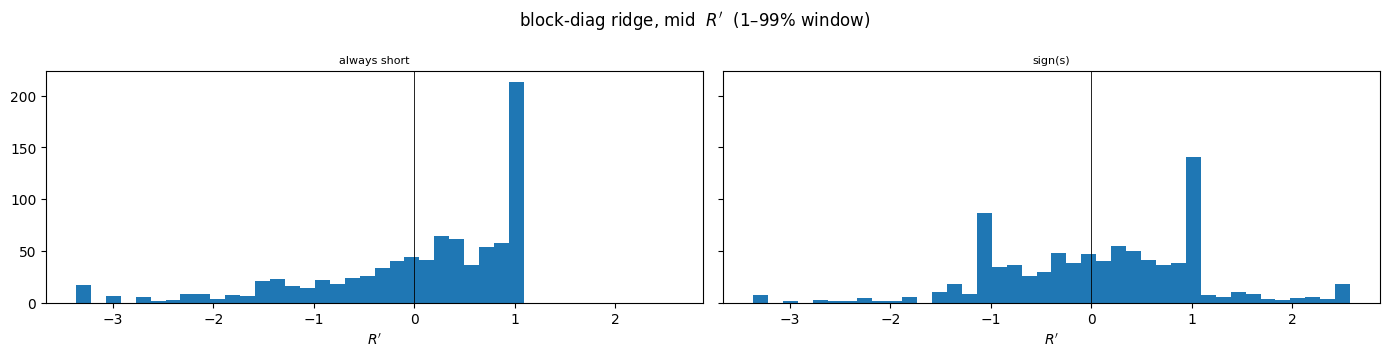

In [11]:
def rule_sizes(px: pd.DataFrame) -> dict[str, pd.Series]:
    return {
        "always short": pd.Series(-1.0, index=px.index),
        "sign(s)": px["pos"],
    }


def rule_row(r: pd.Series, size: pd.Series) -> pd.Series:
    r = pd.Series(r).astype(float)
    size = pd.Series(size, index=r.index).astype(float)
    x = r.dropna()
    n = int(len(x))
    mu = float(x.mean())
    sd = float(x.std(ddof=1))
    n_buy = int((size > 0).sum())
    n_sz = int(size.notna().sum())
    return pd.Series({
        "n": n,
        "mean": mu,
        "std": sd,
        "min": float(x.min()),
        "25%": float(x.quantile(0.25)),
        "50%": float(x.median()),
        "75%": float(x.quantile(0.75)),
        "max": float(x.max()),
        "skew": float(x.skew()),
        "ex_kurt": float(x.kurt()),
        "t_mean": mu / sd * np.sqrt(n) if sd > 0 else float("nan"),
        "Sharpe_ann": mu / sd * np.sqrt(252.0) if sd > 0 else float("nan"),
        "n_buy": n_buy,
        "pct_buy": 100.0 * n_buy / n_sz if n_sz else float("nan"),
    })


order = [
    "always short",
    "sign(s)",
]
cols = ["n", "mean", "std", "min", "25%", "50%", "75%", "max",
        "skew", "ex_kurt", "t_mean", "Sharpe_ann", "n_buy", "pct_buy"]
MODEL_ORDER = ["a0", "blk2", "lgbm", "xgb", "lasso_t", "lasso_f", "enet"]

common = None
for tag in MODEL_ORDER:
    idx = books[tag].index
    common = idx if common is None else common.intersection(idx)
common = common.sort_values()
print("days per model:", {LABEL[t]: len(books[t]) for t in MODEL_ORDER})
print("common days:", len(common),
      pd.Timestamp(common.min()), "->", pd.Timestamp(common.max()))

rule_tabs = {}
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = rule_sizes(px)
    rule_tabs[tag] = pd.DataFrame({
        name: rule_row((sizes[name] * px["R"]).loc[common], sizes[name].loc[common])
        for name in order
    }).T[cols]
    rule_tabs[tag].to_csv(OUT / f"rule_table_{tag}.csv")

for name in order:
    if name == "always short":
        # takes no forecast: every model row is identical, so print one
        # anonymous row (and assert the identity instead of trusting it)
        base = rule_tabs[MODEL_ORDER[0]].loc[name]
        for tag in MODEL_ORDER[1:]:
            assert np.allclose(rule_tabs[tag].loc[name], base), name
        tab = pd.DataFrame({"all models": base}).T[cols]
    else:
        tab = pd.DataFrame(
            {LABEL[tag]: rule_tabs[tag].loc[name] for tag in MODEL_ORDER}
        ).T[cols]
    print(name)
    print(tab.to_string())
    print("---")
    safe = "".join(ch if ch.isalnum() else "_" for ch in name).rstrip("_")
    tab.to_csv(OUT / f"rule_by_strategy_{safe}.csv")
print("saved per-model rule_table_*.csv and per-rule rule_by_strategy_*.csv in", OUT)

fig, axes = plt.subplots(1, len(order), figsize=(14, 3.6), sharex=True, sharey=True)
px = books["blk2"]
sizes = rule_sizes(px)
pooled = pd.concat([sizes[name] * px["R"] for name in order], axis=0).dropna()
lo, hi = float(pooled.quantile(0.01)), float(pooled.quantile(0.99))
bins = np.linspace(lo, hi, 41)
for ax, name in zip(axes.ravel(), order):
    x = (sizes[name] * px["R"]).dropna()
    ax.hist(x.clip(lo, hi), bins=bins, color="C0", edgecolor="none")
    ax.axvline(0.0, color="k", lw=0.6)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel(r"$R'$")
fig.suptitle("block-diag ridge, mid  $R'$  (1–99% window)")
fig.tight_layout()
fig.savefig(OUT / "rule_hists_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "rule_hists_blk2.png")
display(fig)
plt.close(fig)


## 11. Regressing the settlement return on the 15:30 signal

The signal is fixed at 15:30 and the package settles at 16:00 the same
day, so the test pairs $s_t$ with $R_t$; nothing observed after the
decision enters the signal. Per forecast, the plain least-squares fit

$$R_t = a + b\,s_t + \varepsilon_t$$

is reported: the table gives $b$, its $t$-statistic and $R^2$ for the
seven forecasts. The figure, for the block-diagonal ridge forecast,
shows the fit; the mean of $R_t$ on each side of the signal against the
always-short portfolio; and the mean of $R_t$ by level of the signal —
ten equal-count bins of $s_t$, each labelled by its median value in
units of $10^{-6}$ (30-minute variance). Means only; read them against
the $t$-statistics in the table. It is a reading the paper takes up.

least squares of R_t on the 15:30 signal s_t:
                        model                x         a            b       t_b       p_b        R2   n
baseline (HAR + calendar OLS) raw s (same day) -0.019526   655.514259  0.266819  0.789608  0.000038 871
             block-diag ridge raw s (same day) -0.020010  -498.612317 -0.484475  0.628049  0.000108 871
                     LightGBM raw s (same day) -0.020560  1019.285997  3.311186  0.000929  0.000529 871
                      XGBoost raw s (same day) -0.020855  1313.158614  3.592561  0.000327  0.000775 871
       lasso (causally tuned) raw s (same day) -0.020129    39.477941  0.049875  0.960222  0.000001 871
           lasso (fixed 1e-4) raw s (same day) -0.020007  -547.293281 -0.523720  0.600473  0.000131 871
 elastic net (causally tuned) raw s (same day) -0.020117   129.291131  0.194685  0.845640  0.000009 871


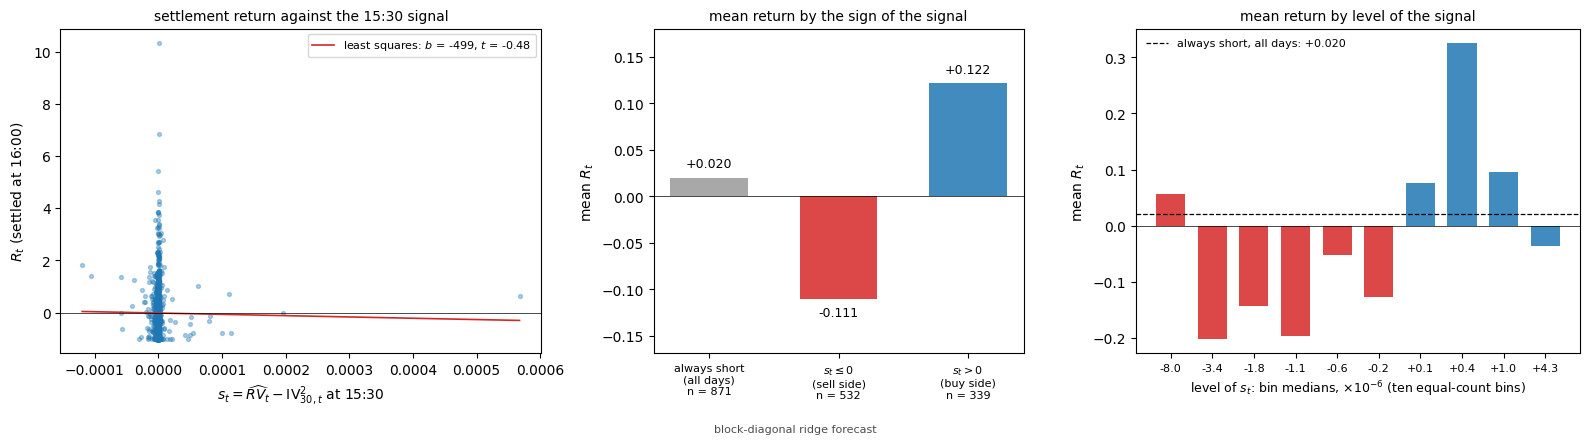

In [12]:
def ls_fit(y, x):
    # least squares fit for the table
    return sm.OLS(y, sm.add_constant(x)).fit(cov_type="HAC", cov_kwds={"maxlags": 6})


reg_rows = []
fig_inputs = None
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    s = px["signal"].astype(float)
    r = px["R"].astype(float)
    ok = np.isfinite(s) & np.isfinite(r)
    fit = ls_fit(r[ok].to_numpy(), s[ok].to_numpy())
    reg_rows.append({"model": LABEL[tag], "x": "raw s (same day)",
                     "a": float(fit.params[0]), "b": float(fit.params[1]),
                     "t_b": float(fit.tvalues[1]), "p_b": float(fit.pvalues[1]),
                     "R2": float(fit.rsquared), "n": int(fit.nobs)})
    if tag == "blk2":
        fig_inputs = (s[ok], r[ok], fit)

reg_tab = pd.DataFrame(reg_rows)
print("least squares of R_t on the 15:30 signal s_t:")
print(reg_tab.to_string(index=False))
reg_tab.to_csv(OUT / "regression_R_on_signal.csv", index=False)

s, r, fit = fig_inputs
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), gridspec_kw={"width_ratios": [1.3, 1, 1.2]})
axes[0].scatter(s, r, s=8, alpha=0.35)
xx = np.linspace(float(s.min()), float(s.max()), 50)
axes[0].plot(xx, fit.params[0] + fit.params[1] * xx, color="C3", lw=1.2,
             label=f"least squares: $b$ = {fit.params[1]:+.0f}, $t$ = {fit.tvalues[1]:+.2f}")
axes[0].axhline(0.0, color="k", lw=0.5)
axes[0].set_xlabel(r"$s_t=\widehat{RV}_t-\mathrm{IV}_{30,t}^2$ at 15:30")
axes[0].set_ylabel(r"$R_t$ (settled at 16:00)")
axes[0].set_title("settlement return against the 15:30 signal", fontsize=10)
axes[0].legend(fontsize=8, loc="upper right")

bench_mean = float((-r).mean())   # the always-short portfolio, the deck's benchmark
stats = [("always short\n(all days)", bench_mean, int(len(r)), "0.6")]
for lab, mask, c in ((r"$s_t \leq 0$" + "\n(sell side)", s <= 0, "C3"),
                     (r"$s_t > 0$" + "\n(buy side)", s > 0, "C0")):
    stats.append((lab, float(r[mask].mean()), int(mask.sum()), c))
top = max(m for _, m, _, _ in stats); bot = min(m for _, m, _, _ in stats)
pad = 0.25 * (top - bot)
for i, (lab, m, n, c) in enumerate(stats):
    axes[1].bar(i, m, color=c, alpha=0.85, width=0.6)
    axes[1].annotate(f"{m:+.3f}", (i, m), xytext=(0, 5 if m >= 0 else -5),
                     textcoords="offset points", ha="center", va="bottom" if m >= 0 else "top", fontsize=9)
axes[1].axhline(0.0, color="k", lw=0.5)
axes[1].set_ylim(bot - pad, top + pad)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([f"{lab}\nn = {n}" for lab, _, n, _ in stats], fontsize=8)
axes[1].set_ylabel(r"mean $R_t$")
axes[1].set_title("mean return by the sign of the signal", fontsize=10)

# mean return by level of the signal: ten equal-count bins of s_t, labelled by the bin median in units of 1e-6
bins = pd.qcut(s, 10, labels=False, duplicates="drop")
levels = s.groupby(bins).median() * 1e6
means = r.groupby(bins).mean()
axes[2].bar(range(len(means)), means.to_numpy(), color=["C3" if v <= 0 else "C0" for v in levels], alpha=0.85, width=0.7)
axes[2].axhline(bench_mean, color="k", lw=0.9, ls="--", label=f"always short, all days: {bench_mean:+.3f}")
axes[2].axhline(0.0, color="k", lw=0.5)
axes[2].set_xticks(range(len(means)))
axes[2].set_xticklabels([f"{v:+.1f}" for v in levels], fontsize=8)
axes[2].set_xlabel(r"level of $s_t$: bin medians, $\times 10^{-6}$ (ten equal-count bins)", fontsize=9)
axes[2].set_ylabel(r"mean $R_t$")
axes[2].set_title("mean return by level of the signal", fontsize=10)
axes[2].legend(fontsize=8, loc="upper left", frameon=False)
fig.text(0.5, 0.005, "block-diagonal ridge forecast", ha="center", fontsize=8, color="0.3")
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(OUT / "regression_R_on_signal_blk2.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 12. Profit and loss, without compounding

Same contracts and positions as the rule table; every series is a daily
quantity, **summed, not compounded**. Notation for one day: position
$q\in\{-1,+1\}$, entry midpoint $P=\mathrm{mid}_c+\mathrm{mid}_p$, bid
and ask sums $P_b$, $P_a$, half-spread $h=\tfrac12(P_a-P_b)$, settlement
payout $X$, contract multiplier $M=100$.

$$
\begin{aligned}
\text{mid premium return}\quad & R' = q\,\Bigl(\frac{X}{P}-1\Bigr) \\[2pt]
\text{crossed spread}\quad & R'_{\times} =
  \begin{cases} X/P_a-1, & q>0 \\ 1-X/P_b, & q<0 \end{cases} \\[2pt]
\text{half-spread cost}\quad & R'_{h} = \frac{q\,\bigl(X-(P+q\,h)\bigr)}{P} = R'-\frac{h}{P} \\[2pt]
\text{index points}\quad & \Pi = q\,(X-P) \\[2pt]
\text{dollars}\quad & \Pi_{\$} = M\,\Pi \\[2pt]
\text{margin-scaled}\quad & R'_{m} = \frac{\Pi_{\$}}{C},\qquad
  C=\begin{cases} M\,m, & q<0 \\ M\,P, & q>0 \end{cases}
\end{aligned}
$$

with the short-side capital an exchange-style short-straddle margin,

$$
m=\max\bigl(0.15\,S-\mathrm{OTM}+P,\;0.10\,S+P,\;0\bigr),\qquad
\mathrm{OTM}=\min\bigl(|S-K_c|,\,|S-K_p|\bigr).
$$

The published series is the first line, filled at the midpoint. The plot
is $\sum_t \Pi_{\$,t}$ for the midpoint and crossed-spread fills.

        rule         variant   unit           n       mean         std          min         25%         50%         75%          max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
always short   mid premium R return  871.000000   0.020132    1.126834   -10.316049   -0.443536    0.328935    0.931263     1.000000 -2.314322  10.899722  0.527286    0.283620    0.000000   0.000000
always short  crossed spread return  869.000000  -0.016758    1.170403   -10.954858   -0.491659    0.306209    0.928938     1.000000 -2.363537  11.574814 -0.422072   -0.227288    0.000000   0.000000
always short  half-spread TC return  871.000000  -0.016799    1.125441   -10.369484   -0.473872    0.293954    0.886394     0.988372 -2.323473  11.011118 -0.440517   -0.236948    0.000000   0.000000
always short index-point P&L points  871.000000   0.021117    7.885921   -78.370018   -2.390039    1.724805    3.972510    21.890137 -2.602497  16.119768  0.079031    0.042510    0.000000   0.000000
alway

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\pnl_cum_usd_blk2.png


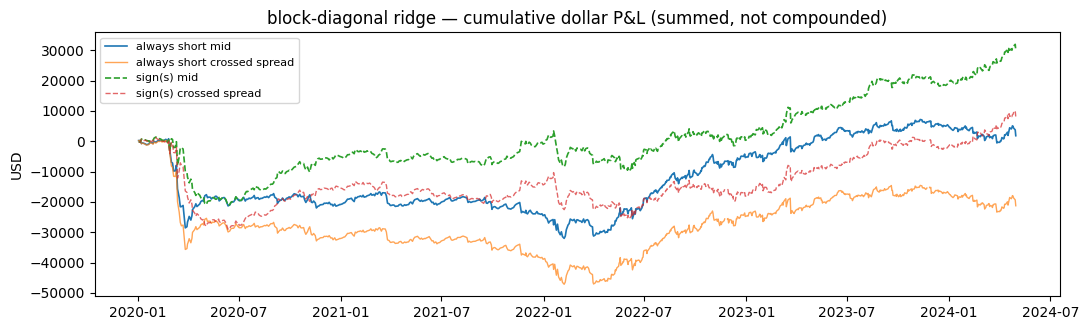

In [13]:
import sys
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl

px = books["blk2"].loc[common].copy()
if "bid_entry" not in px.columns:
    px["bid_entry"] = px["bid_c"].astype(float) + px["bid_p"].astype(float)
    px["ask_entry"] = px["ask_c"].astype(float) + px["ask_p"].astype(float)
hs = 0.5 * (px["ask_entry"] - px["bid_entry"])
sizes = rule_sizes(books["blk2"])
rows = []

def add_variant(series, q, rule, variant, unit):
    st = asl.rule_row(series, q)
    rows.append({"rule": rule, "variant": variant, "unit": unit, **st.to_dict()})

for name in ("always short", "sign(s)"):
    q = sizes[name].loc[common]
    mid = (q * px["R"])
    add_variant(mid, q, name, "mid premium R", "return")
    signq = np.sign(q.replace(0, -1.0))
    crossed = asl.crossed_premium_return(signq, px["exit"], px["bid_entry"], px["ask_entry"]) * q.abs()
    add_variant(crossed, q, name, "crossed spread", "return")
    trade = px["entry"] + signq * hs
    tc = q * (px["exit"] - trade) / px["entry"]
    add_variant(tc, q, name, "half-spread TC", "return")
    pts = asl.points_pnl(q, px["exit"], px["entry"])
    add_variant(pts, q, name, "index-point P&L", "points")
    usd = pts * asl.SPX_MULTIPLIER
    add_variant(usd, q, name, "dollar P&L", "USD")
    margin_pts = [
        asl.cboe_short_straddle_margin_points(S, Kc, Kp, ent)
        for S, Kc, Kp, ent in zip(px["S"], px["K_c"], px["K_p"], px["entry"])
    ]
    margin_pts = pd.Series(margin_pts, index=px.index)
    capital = np.where(q < 0, margin_pts * asl.SPX_MULTIPLIER, px["entry"] * asl.SPX_MULTIPLIER)
    mret = usd / np.maximum(capital, 1e-8)
    add_variant(pd.Series(mret, index=px.index), q, name, "margin-scaled", "return")

var_tab = pd.DataFrame(rows)
print(var_tab.to_string(index=False))
var_tab.to_csv(OUT / "pnl_variants_blk2.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 3.4))
for name, ls in (("always short", "-"), ("sign(s)", "--")):
    q = sizes[name].loc[common]
    ax.plot(
        px.index,
        asl.points_pnl(q, px["exit"], px["entry"]).cumsum() * asl.SPX_MULTIPLIER,
        ls, lw=1.2, label=f"{name} mid",
    )
    signq = np.sign(q.replace(0, -1.0))
    crossed_usd = (asl.crossed_premium_return(signq, px["exit"], px["bid_entry"], px["ask_entry"]) * q.abs() * px["entry"] * asl.SPX_MULTIPLIER)
    ax.plot(px.index, crossed_usd.cumsum(), ls, lw=1.0, alpha=0.7, label=f"{name} crossed spread")
ax.set_title("block-diagonal ridge — cumulative dollar P&L (summed, not compounded)")
ax.set_ylabel("USD")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "pnl_cum_usd_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "pnl_cum_usd_blk2.png")
display(fig)
plt.close(fig)


## 13. Information ratio against always-short

The benchmark is the always-short portfolio, $R^{\mathrm{AS}}_t=-R_t$: one short package every day. The active portfolio is the $\mathrm{sign}(s)$ portfolio, $R^p_t=q_t R_t$ with $q_t=\mathrm{sign}(s_t)$.

The **active return** is the daily difference $R^a_t=R^p_t-R^{\mathrm{AS}}_t$. On short days $q_t=-1$ and the two portfolios coincide, so $R^a_t=0$. On buy days the position has flipped from short to long, so $R^a_t=q_tR_t-(-R_t)=(q_t+1)R_t$, which equals $2R_t$ for a $\pm1$ position. The series is those daily differences on the 871 common days.

The table's columns are:

- the **mean active return** (`mean_active`), the sample mean of that daily series, not annualized;
- the **tracking error**, the standard deviation of the active return with $n-1$ in the denominator, reported daily (`te_daily`) and annualized by $\sqrt{252}$ (`te_ann`);
- the **annualized information ratio** (`IR_ann`), $\overline{R^a}/\mathrm{std}(R^a)\times\sqrt{252}$, which equals the mean active return over the annualized tracking error — the Sharpe ratio of the *active* series, not of $R^p$;
- the **$t$-statistic of the active return** (`t_active`), $\overline{R^a}/\mathrm{std}(R^a)\times\sqrt{n}$, the usual test that the mean active return is zero — the same algebra as the $t$-statistic in the rule table, applied to $R^a$; the information ratio and this $t$ move together, but $t$ is not annualized;
- the **correlation to the benchmark** (`corr_to_bench`), $\mathrm{corr}(R^p,R^{\mathrm{AS}})$.

In [14]:
ir_rows = []
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = rule_sizes(px)
    bench = (sizes["always short"] * px["R"]).loc[common]
    for name in ("sign(s)",):
        port = (sizes[name] * px["R"]).loc[common]
        st = asl.information_ratio(port, bench)
        ir_rows.append({"model": LABEL[tag], "rule": name, **st.to_dict()})
ir_tab = (
    pd.DataFrame(ir_rows)
    .set_index(["rule", "model"])
    .sort_values(by="IR_ann", ascending=False)
    .sort_index(level="rule", sort_remaining=False)
)
print(ir_tab.to_string())
ir_tab.to_csv(OUT / "information_ratio_vs_always_short.csv")
print("IR = active return / tracking error; benchmark is always-short.")


                                                n  mean_active  te_daily     te_ann    IR_ann  t_active  corr_to_bench
rule    model                                                                                                         
sign(s) lasso (fixed 1e-4)             871.000000     0.109708  1.767254  28.054288  0.985457  1.832089      -0.237873
        block-diag ridge               871.000000     0.095078  1.670489  26.518185  0.903514  1.679746      -0.104451
        lasso (causally tuned)         871.000000     0.081926  1.575644  25.012566  0.825399  1.534520       0.018516
        XGBoost                        871.000000     0.078055  1.547942  24.572817  0.800474  1.488183       0.053014
        LightGBM                       871.000000     0.074126  1.560043  24.764921  0.754281  1.402304       0.038437
        elastic net (causally tuned)   871.000000     0.060354  1.533247  24.339547  0.624877  1.161725       0.072070
        baseline (HAR + calendar OLS)  871.00000

## 14. Betting a fixed fraction of wealth

Every table so far adds up one unit of premium per day. Here each rule
reinvests: a **fixed** share $f$ of current wealth is deployed as body
premium every day, the same number on every day and for both rules,

$$
f = 0.03, \qquad
W_T=\prod_{t}\bigl(1+f\,q_t R_t\bigr), \qquad
g = 252\cdot\overline{\log\bigl(1+f\,R'_t\bigr)},
$$

with $R'_t=q_tR_t$ the rule's daily return and $g$ the annualized
log-growth. The number is a chosen round figure, not fitted. Ruin is one
bad day: wealth reaches zero on the worst day once
$f \ge 1/|\min_t R'_t|$, and the worst single-day wealth factor is
$1+f\min_t R'_t$; both are printed per rule.

block-diagonal ridge - fixed fraction f = 0.03 of wealth per day, 871 common days
rule              always short     sign(s)
f                     0.030000    0.030000
g_ann                -0.000380    0.730185
terminal              0.998689   12.475576
maxDD                -0.521586   -0.439343
worst_day_factor      0.690519    0.837326
ruin_bound_f          0.096936    0.184417
n                   871.000000  871.000000
saved fixedfrac_summary_<model>.csv in C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530
---
terminal wealth across models, both rules
rule                           always short  sign(s)
model                                               
baseline (HAR + calendar OLS)          1.00     3.87
block-diag ridge                       1.00    12.48
elastic net (causally tuned)           1.00     5.00
lasso (fixed 1e-4)                     1.00    18.36
lasso (causally tuned)                 1.00     8.79
LightGBM                              

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\fixedfrac_wealth_blk2.png


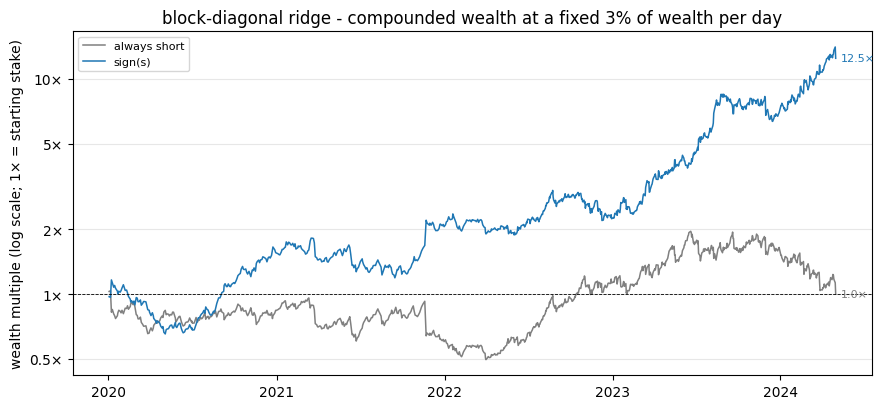

In [15]:
F_FIXED = 0.03  # share of wealth deployed as body premium, every day


def wealth_stats(f, r):
    factors = 1.0 + f * np.asarray(r, float)
    assert (factors > 0).all(), "a wealth factor hit zero - ruin"
    w = np.cumprod(factors)
    return pd.Series({
        "f": f,
        "g_ann": 252.0 * float(np.mean(np.log(factors))),
        "terminal": float(w[-1]),
        "maxDD": float((w / np.maximum.accumulate(w) - 1.0).min()),
        "worst_day_factor": float(factors.min()),
        "ruin_bound_f": 1.0 / abs(float(np.min(r))),
        "n": len(r),
    })


def wealth_axis(ax):
    # log-scaled axis labelled in wealth multiples; 1x = the starting stake
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(FixedLocator([0.25, 0.5, 1, 2, 5, 10, 20, 50, 100]))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}×"))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.axhline(1.0, color="k", lw=0.6, ls="--")
    ax.grid(axis="y", which="major", alpha=0.3)
    ax.set_ylabel("wealth multiple (log scale; 1× = starting stake)")


ff_rows = {}
for tag in MODEL_ORDER:
    px = books[tag]
    for name, q in rule_sizes(px).items():
        rs = (q * px["R"]).loc[common].astype(float)
        ff_rows[(name, tag)] = wealth_stats(F_FIXED, rs.to_numpy())
ff_tab = pd.DataFrame(ff_rows).T
ff_tab.index = pd.MultiIndex.from_tuples(ff_tab.index, names=["rule", "model"])
for tag in MODEL_ORDER:
    safe = "".join(ch if ch.isalnum() else "_" for ch in tag).rstrip("_")
    ff_tab.xs(tag, level="model").to_csv(OUT / f"fixedfrac_summary_{safe}.csv")
print(f"block-diagonal ridge - fixed fraction f = {F_FIXED:.2f} of wealth per day, {len(common)} common days")
print(ff_tab.xs("blk2", level="model").T.to_string())
print("saved fixedfrac_summary_<model>.csv in", OUT)
print("---")
print("terminal wealth across models, both rules")
print(ff_tab["terminal"].unstack("rule").rename(index=LABEL).to_string(float_format=lambda x: f"{x:.2f}"))

px = books["blk2"]
for name in ("always short", "sign(s)"):
    rs = (rule_sizes(px)[name] * px["R"]).loc[common].astype(float)
    gy = pd.Series(np.log1p(F_FIXED * rs.to_numpy()), index=rs.index)
    print(f"per-year annualized log-growth, block-diagonal ridge, {name}:")
    print((252.0 * gy.groupby(gy.index.year).mean()).to_string(float_format=lambda x: f"{x:+.3f}"))

import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(9, 4.2))
for name, c in (("always short", "0.5"), ("sign(s)", "C0")):
    rs = (rule_sizes(px)[name] * px["R"]).loc[common].astype(float)
    w = np.cumprod(1.0 + F_FIXED * rs.to_numpy())
    ax.plot(rs.index, w, lw=1.1, color=c, label=name)
    ax.annotate(f"{w[-1]:.1f}×", (rs.index[-1], w[-1]), xytext=(4, 0), textcoords="offset points",
                fontsize=8, va="center", color=c)
wealth_axis(ax)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title(f"block-diagonal ridge - compounded wealth at a fixed {F_FIXED:.0%} of wealth per day")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "fixedfrac_wealth_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "fixedfrac_wealth_blk2.png")
display(fig)
plt.close(fig)


## 15. When does each forecast say buy?

A buy day is one with $q_t>0$. The always-short rule never buys. The
forecasts are compared on the days they share.

                        model  n_buy    pct_buy  mean_R|buy  mean_R|sell  median_|s|_buy
baseline (HAR + calendar OLS)    280  32.146958    0.078543    -0.066882        0.000001
             block-diag ridge    339  38.920781    0.122142    -0.110793        0.000001
                     LightGBM    282  32.376579    0.114475    -0.084579        0.000001
                      XGBoost    275  31.572905    0.123611    -0.086457        0.000001
       lasso (causally tuned)    320  36.739380    0.111496    -0.096577        0.000001
           lasso (fixed 1e-4)    365  41.905855    0.130898    -0.129077        0.000001
 elastic net (causally tuned)    303  34.787600    0.086746    -0.077147        0.000001
always-short n_buy = 0.
Jaccard of buy-day sets
                               baseline (HAR + calendar OLS)  block-diag ridge  LightGBM   XGBoost  lasso (causally tuned)  lasso (fixed 1e-4)  elastic net (causally tuned)
baseline (HAR + calendar OLS)                       1.000000       

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\buy_signal_diag_blk2.png


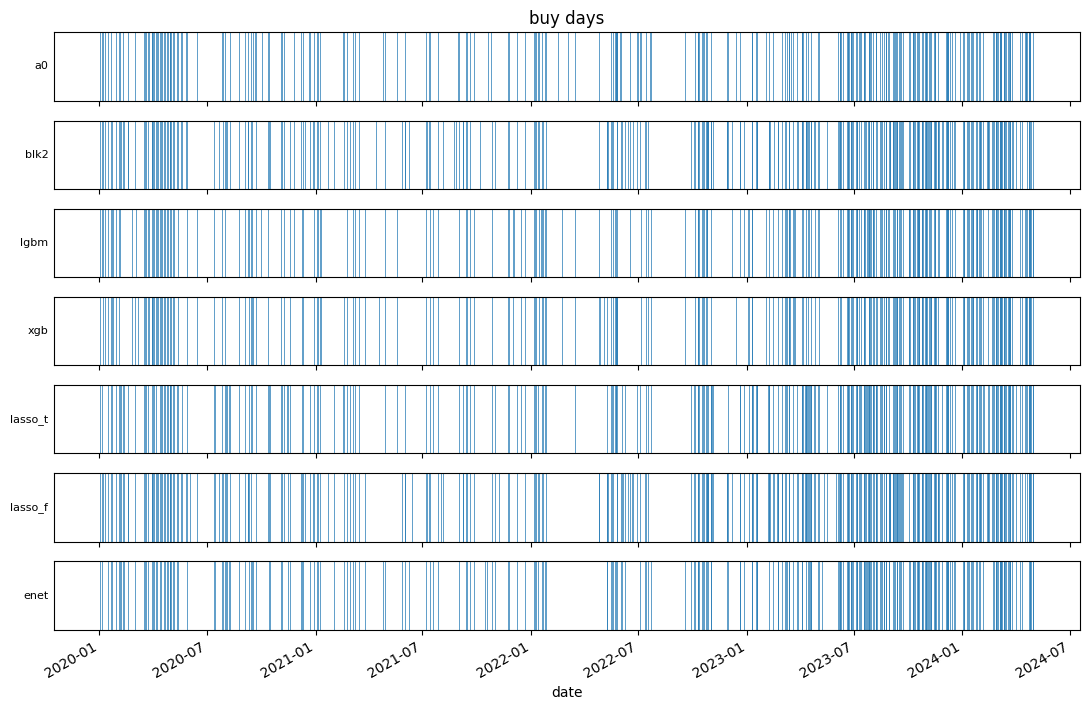

In [16]:
buy = {}
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    buy[tag] = (px["pos"] > 0)
diag_rows = []
for tag in MODEL_ORDER:
    b = buy[tag]
    px = books[tag].loc[common]
    diag_rows.append({
        "model": LABEL[tag],
        "n_buy": int(b.sum()),
        "pct_buy": 100.0 * float(b.mean()),
        "mean_R|buy": float(px.loc[b, "R"].mean()) if b.any() else float("nan"),
        "mean_R|sell": float(px.loc[~b, "R"].mean()),
        "median_|s|_buy": float(px.loc[b, "signal"].abs().median()) if b.any() else float("nan"),
    })
print(pd.DataFrame(diag_rows).to_string(index=False))
print("always-short n_buy = 0.")

jacc = pd.DataFrame(index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
for a in MODEL_ORDER:
    for b in MODEL_ORDER:
        u = buy[a] | buy[b]
        jacc.loc[a, b] = float((buy[a] & buy[b]).sum() / u.sum()) if u.any() else 1.0
jacc.index = [LABEL[t] for t in MODEL_ORDER]
jacc.columns = jacc.index
print("Jaccard of buy-day sets")
print(jacc.round(3).to_string())
jacc.to_csv(OUT / "buy_signal_agreement.csv")
off = jacc.values[np.triu_indices(len(jacc), 1)]
print(f"mean pairwise Jaccard {float(off.mean()):.3f}")

idx = pd.DatetimeIndex(common)
fig, axes = plt.subplots(len(MODEL_ORDER), 1, figsize=(11, 7.2), sharex=True)
for ax, tag in zip(axes, MODEL_ORDER):
    days = idx[buy[tag].to_numpy()]
    ax.vlines(days, 0, 1, color="C0", lw=0.5)
    ax.set_yticks([])
    ax.set_ylabel(tag, rotation=0, ha="right", va="center", fontsize=8)
    ax.set_ylim(0, 1)
axes[-1].set_xlabel("date")
axes[0].set_title("buy days")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "buy_signal_diag_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "buy_signal_diag_blk2.png")
display(fig)
plt.close(fig)


## 16. Checking one row by hand

The columns of a single row map onto the construction as follows.

- `K_c >= S` and `K_p <= S` at 15:30: the call strike sits at or
  above the spot and the put strike at or below it.
- `entry` is the 15:30 midpoint quote of the package, `mid_c + mid_p`.
- `exit` is the cash settlement,
  `max(S_close - K_c, 0) + max(K_p - S_close, 0)`, with `S_close`
  the official close from yfinance `^GSPC`.
- `R` is `exit/entry - 1`.
- `yhat` is the forecast on the fitted scale, $\widehat{\sqrt{RV/B}}$;
  `rv_hat = (m^2 + s2) * B` converts it to a 30-minute variance.
- The quoted implied volatility is hourly, so
  `iv_30 = iv_hourly / sqrt(2)` and `iv_var = iv_30**2`.
- `signal = rv_hat - iv_var`; the variance risk premium is
  $\mathrm{VRP}=-s$. The sign(s) position `pos` is $+1$
  when the signal is positive and $-1$ otherwise.

---

*Housekeeping note (2026-09-02, not analysis).* Repo state to clean up
later. The two working directories are worktrees of one repo on sibling
branches that diverged at `5db8240`: this branch
(`grok/0dte-professor-notes`, +15) carries all the notebook work and
the close-option writeup prose; `paper2` (+1, `d3809a4`) carries the
F$_t$-measurability scorer fixes and the honest options macros in
`writeup/generated/`. The writeup therefore has two truths pending
consolidation (both options narratives are parked, so nothing renders
wrong yet). Plan sketched: (a) merge this branch into `paper2` (merge,
not rebase) and fast-forward this branch to the merge; (b) fast-forward
local `main` (behind `origin/main` by 6 campaign-sync commits that are
already ancestors of `paper2`); (c) fix `paper2`'s upstream (tracks
`origin/main`, should be `origin/paper2`) and delete-or-archive the two
dead local branches (`edge-features-legibility`,
`prop-exploration-2026-07-02`, upstreams gone); (d) untrack LaTeX aux
and volatile `.hpc` state via `.gitignore` to stop the chronic dirty
tree; (e) review the real uncommitted diffs in `harxhar-clean`
(`experiments/run_geometry_local.py`, spec/pack jsons) before touching
anything. Open decision: one unified line vs keeping this branch as a
deliberate fork; delete vs archive for the dead branches.